# Skeletal Variation Analysis

This notebook analyzes skeletal variation across:
- the adult human skeleton
- mammal neck vertebrae
- bird neck vertebrae

## Goals
- explore how bones are distributed across body regions in humans
- measure how many bones are fused in the adult human body
- compare neck vertebrae patterns in mammals and birds
- identify species with unusually high or low vertebrae counts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
human = pd.read_csv('adult-human-skeleton.csv')
mammals = pd.read_csv('mammal-neck-bones.csv')
birds = pd.read_csv('bird-neck-bones.csv')

In [3]:
display(human.head())
display(mammals.head())
display(birds.head())

,name,region,subregion,side,fused_from
0,frontal,head,cranium,center,2
1,left parietal,head,cranium,left,1
2,right parietal,head,cranium,right,1
3,left temporal,head,cranium,left,1
4,right temporal,head,cranium,right,1


,species,neck_vertebrae
0,cheetah,7
1,impala,7
2,giant panda,7
3,hartebeest,7
4,moose,7


,species,neck_vertebrae
0,cinereous vulture,13
1,guineafowl,14
2,red-legged partridge,14
3,blue-cheeked parrot,12
4,northern pintail,15


In [4]:
print("Human dataset shape:", human.shape)
print("Mammals dataset shape:", mammals.shape)
print("Birds dataset shape:", birds.shape)

Human dataset shape: (206, 5)
Mammals dataset shape: (302, 2)
Birds dataset shape: (81, 2)


In [5]:
print("Missing values in human dataset:")
display(human.isna().sum())

print("Missing values in mammal dataset:")
display(mammals.isna().sum())

print("Missing values in bird dataset:")
display(birds.isna().sum())

Missing values in human dataset:


name          0
region        0
subregion     0
side          0
fused_from    0
dtype: int64

Missing values in mammal dataset:


species           0
neck_vertebrae    0
dtype: int64

Missing values in bird dataset:


species           0
neck_vertebrae    0
dtype: int64

In [7]:
def contains_text(data, column, text):
    return data[data[column].str.contains(text, case=False, na=False)]

def species_with_extreme(data, column, find='max'):
    idx = data[column].idxmax() if find == 'max' else data[column].idxmin()
    return data.loc[idx]

def region_summary(data):
    return (
        data.groupby('region')
            .agg(
                bone_count=('name', 'count'),
                total_fused_from=('fused_from', 'sum')
            )
            .sort_values('bone_count', ascending=False)
    )

## Human Skeleton Analysis

First, we examine how bones are distributed across body regions in the adult human skeleton.

In [10]:
# Count bones by region
human_region_counts = human['region'].value_counts().sort_values(ascending=False)
human_region_counts

region
hand     54
foot     52
torso    50
head     28
neck      8
leg       8
arm       6
Name: count, dtype: int64

In [11]:
# More polished summary table by region
human_region_summary = region_summary(human)
human_region_summary

,bone_count,total_fused_from
region,,
hand,54,54
foot,52,52
torso,50,104
head,28,39
leg,8,16
neck,8,26
arm,6,14


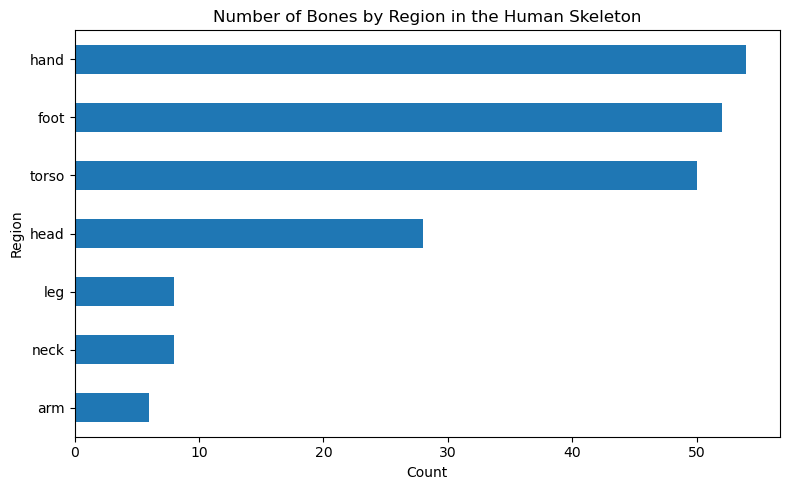

In [12]:
# Plot bones by region
human_region_counts.sort_values().plot.barh(figsize=(8, 5))
plt.title('Number of Bones by Region in the Human Skeleton')
plt.xlabel('Count')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

In [13]:
# Proportion of bones in the hands and feet
hand_foot_bones = human[human['region'].isin(['hand', 'foot'])].shape[0]
total_bones = len(human)
hand_foot_proportion = hand_foot_bones / total_bones

print("Bones in hands and feet:", hand_foot_bones)
print("Total bones:", total_bones)
print("Proportion:", round(hand_foot_proportion, 3))
print("Percentage:", round(hand_foot_proportion * 100, 2), "%")

Bones in hands and feet: 106
Total bones: 206
Proportion: 0.515
Percentage: 51.46 %


In [14]:
# Bones formed by fusion
human_sorted_fusion = human.sort_values(by='fused_from', ascending=False)
human_sorted_fusion.head(10)

,name,region,subregion,side,fused_from
40,sternum,torso,chest,center,6
82,sacrum,torso,pelvis,center,5
30,c2,neck,vertebra,center,5
83,coccyx,torso,pelvis,center,4
5,occipital,head,cranium,center,4
31,c3,neck,vertebra,center,3
86,left humerus,arm,upper-arm,left,3
87,right humerus,arm,upper-arm,right,3
146,left femur,leg,upper-leg,left,3
28,hyoid,neck,throat,center,3


In [15]:
# Total number of original bones before fusion
total_original_bones = human['fused_from'].sum() + len(human)

print("Total adult bones:", len(human))
print("Total bones fused from earlier bones:", human['fused_from'].sum())
print("Estimated original bone count before fusion:", total_original_bones)

Total adult bones: 206
Total bones fused from earlier bones: 305
Estimated original bone count before fusion: 511


In [16]:
# Bones in the neck
neck_bones = human.query('region == "neck"')
display(neck_bones)

print("Number of neck bones in this dataset:", neck_bones.shape[0])

,name,region,subregion,side,fused_from
28,hyoid,neck,throat,center,3
29,c1,neck,vertebra,center,3
30,c2,neck,vertebra,center,5
31,c3,neck,vertebra,center,3
32,c4,neck,vertebra,center,3
33,c5,neck,vertebra,center,3
34,c6,neck,vertebra,center,3
35,c7,neck,vertebra,center,3


Number of neck bones in this dataset: 8


In [17]:
# Compare arm vs leg
arm_leg_counts = (
    human[human['region'].isin(['arm', 'leg'])]
    .groupby('region')['name']
    .count()
    .sort_values(ascending=False)
)

arm_leg_counts

region
leg    8
arm    6
Name: name, dtype: int64

In [18]:
# Find ribs
ribs = contains_text(human, 'name', 'rib')
display(ribs)

print("Total number of ribs:", ribs.shape[0])

,name,region,subregion,side,fused_from
41,left rib 1,torso,chest,left,1
42,left rib 2,torso,chest,left,1
43,left rib 3,torso,chest,left,1
44,left rib 4,torso,chest,left,1
45,left rib 5,torso,chest,left,1
46,left rib 6,torso,chest,left,1
47,left rib 7,torso,chest,left,1
48,left rib 8,torso,chest,left,1
49,left rib 9,torso,chest,left,1
50,left rib 10,torso,chest,left,1


Total number of ribs: 24


## Mammal Neck Vertebrae Analysis

Next, we examine whether mammals generally share the same number of neck vertebrae.

In [20]:
# Summary statistics for mammal neck vertebrae
mammals['neck_vertebrae'].describe()

count    302.000000
mean       7.006623
std        0.182150
min        6.000000
25%        7.000000
50%        7.000000
75%        7.000000
max        9.000000
Name: neck_vertebrae, dtype: float64

In [21]:
# Distribution of mammal neck vertebrae counts
mammal_counts = mammals['neck_vertebrae'].value_counts().sort_index()
mammal_counts

neck_vertebrae
6      2
7    298
9      2
Name: count, dtype: int64

In [22]:
# Giraffe rows
giraffes = mammals.query('species == "giraffe"')
giraffes

,species,neck_vertebrae
108,giraffe,7


In [23]:
# Mammals that do not have 7 neck vertebrae
mammals_not_7 = mammals.query('neck_vertebrae != 7')
mammals_not_7

,species,neck_vertebrae
27,pale-throated sloth,9
28,brown-throated sloth,9
60,hoffmann's two-toed sloth,6
291,west indian manatee,6


In [24]:
print("Number of mammals not equal to 7 vertebrae:", mammals_not_7.shape[0])

Number of mammals not equal to 7 vertebrae: 4


## Bird Neck Vertebrae Analysis

Birds are known to have much more variation in neck vertebrae than mammals.

In [25]:
# Summary statistics for bird neck vertebrae
birds['neck_vertebrae'].describe()

count    81.000000
mean     14.037037
std       2.352894
min      10.000000
25%      12.000000
50%      13.000000
75%      15.000000
max      23.000000
Name: neck_vertebrae, dtype: float64

In [26]:
# Distribution of bird neck vertebrae
bird_counts = birds['neck_vertebrae'].value_counts().sort_index()
bird_counts

neck_vertebrae
10     1
11     7
12    13
13    20
14    14
15     7
16     5
17     6
18     5
19     2
23     1
Name: count, dtype: int64

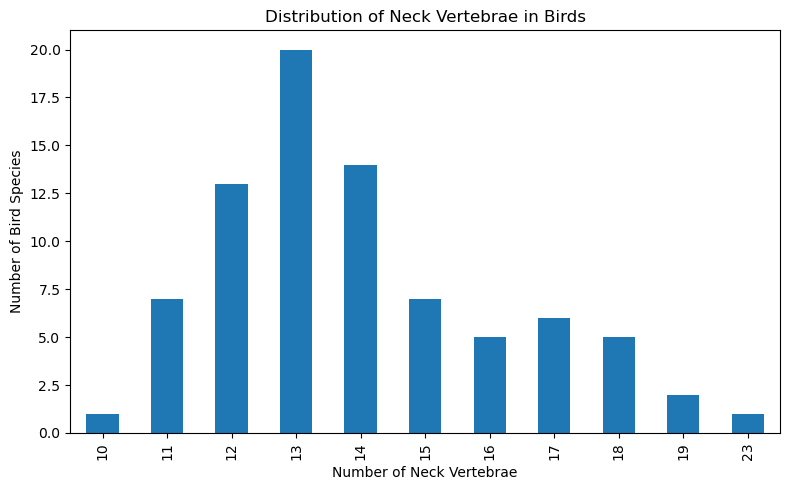

In [27]:
# Plot bird vertebrae distribution
bird_counts.plot.bar(figsize=(8, 5))
plt.title('Distribution of Neck Vertebrae in Birds')
plt.xlabel('Number of Neck Vertebrae')
plt.ylabel('Number of Bird Species')
plt.tight_layout()
plt.show()

In [28]:
# Bird with the maximum number of neck vertebrae
bird_max = species_with_extreme(birds, 'neck_vertebrae', find='max')
bird_max

species           mute swan
neck_vertebrae           23
Name: 28, dtype: object

In [29]:
# Bird with the minimum number of neck vertebrae
bird_min = species_with_extreme(birds, 'neck_vertebrae', find='min')
bird_min

species           blue-and-yellow macaw
neck_vertebrae                       10
Name: 11, dtype: object

In [30]:
print("Bird with most neck vertebrae:")
display(bird_max)

print("Bird with fewest neck vertebrae:")
display(bird_min)

Bird with most neck vertebrae:


species           mute swan
neck_vertebrae           23
Name: 28, dtype: object

Bird with fewest neck vertebrae:


species           blue-and-yellow macaw
neck_vertebrae                       10
Name: 11, dtype: object

## Cross-Dataset Comparison

Finally, we compare the major patterns across humans, mammals, and birds.

In [32]:
comparison = pd.DataFrame({
    'dataset': ['Human Skeleton', 'Mammals', 'Birds'],
    'rows': [len(human), len(mammals), len(birds)],
    'main_measure': ['Bones', 'Neck vertebrae', 'Neck vertebrae'],
    'minimum': [None, mammals['neck_vertebrae'].min(), birds['neck_vertebrae'].min()],
    'maximum': [None, mammals['neck_vertebrae'].max(), birds['neck_vertebrae'].max()],
    'average': [None, mammals['neck_vertebrae'].mean(), birds['neck_vertebrae'].mean()]
})

comparison

,dataset,rows,main_measure,minimum,maximum,average
0,Human Skeleton,206,Bones,NaN,NaN,NaN
1,Mammals,302,Neck vertebrae,6.0,9.0,7.006623
2,Birds,81,Neck vertebrae,10.0,23.0,14.037037


## Findings

### Human skeleton
- A large share of bones are concentrated in the hands and feet.
- Some adult bones are formed by fusion of earlier bones.
- The leg region contains more bones than the arm region.
- Humans have 24 ribs in total.

### Mammals
- Most mammals in the dataset have 7 neck vertebrae.
- Only a small number of mammals differ from this pattern.
- Even giraffes still follow the common mammalian pattern.

### Birds
- Birds show much more variation in neck vertebrae than mammals.
- Some bird species have very high vertebrae counts, while others have much fewer.
- This suggests bird neck anatomy is more flexible and variable across species.